<a href="https://colab.research.google.com/github/Netra895/231A013_NLP-Experiments/blob/main/AIDS_Sem7_NLP_Experiment10/NLP_EXP_NO_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
print("Name: Netra Neman, UIN: 231A013")
import pandas as pd
from datasets import load_dataset

# Load complete IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")

Name: Netra Neman, UIN: 231A013


In [4]:
print("Name: Netra Neman, UIN: 231A013")
df = pd.concat(
    [dataset['train'].to_pandas(),
     dataset['test'].to_pandas()],
    ignore_index=True
)

df = df.rename(columns = {"labels": "labels"})

print(df.shape)
print(df.columns)
df.head()

Name: Netra Neman, UIN: 231A013
(50000, 2)
Index(['text', 'label'], dtype='object')


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [6]:
print("Name: Netra Neman, UIN: 231A013")
df['label'].count()

Name: Netra Neman, UIN: 231A013


np.int64(50000)

In [8]:
print("Name: Netra Neman, UIN: 231A013")
print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicates rows:")
print(df.duplicated().sum())

df["char_count"] = df["text"].astype(str).apply(len)

df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

df["unique_word_count"] = df["text"].astype(str).apply(lambda x: len(set(x.lower().split())))

df["avg_word_length"] = df["text"].astype(str).apply(lambda x: sum(len(word) for word in x.split()) / max(len(x.split()), 1))

print("\nText statistics:")
print(df[["char_count", "word_count", "unique_word_count", "avg_word_length"]].describe())

Name: Netra Neman, UIN: 231A013

Missing values:
text     0
label    0
dtype: int64

Number of duplicates rows:
418

Text statistics:
         char_count    word_count  unique_word_count  avg_word_length
count  50000.000000  50000.000000       50000.000000     50000.000000
mean    1309.431020    231.156940         148.049780         4.640676
std      989.728014    171.343997          88.837364         0.340731
min       32.000000      4.000000           4.000000         1.239865
25%      699.000000    126.000000          91.000000         4.417904
50%      970.000000    173.000000         120.000000         4.627006
75%     1590.250000    280.000000         180.000000         4.847458
max    13704.000000   2470.000000        1092.000000        12.290909


In [10]:
print("Name: Netra Neman, UIN: 231A013")
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text)  # Replaces multiple whitespaces with a single space
    return text.strip()

df["clean_text"] = df["text"].astype(str).apply(clean_text)

print("\nOriginal review (first 150 chars):")
print(df["text"].iloc[0][:150])

print("\nCleaned review (first 150 chars):")
print(df["clean_text"].iloc[0][:150])

Name: Netra Neman, UIN: 231A013

Original review (first 150 chars):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th

Cleaned review (first 150 chars):
i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at f


Name: Netra Neman, UIN: 231A013


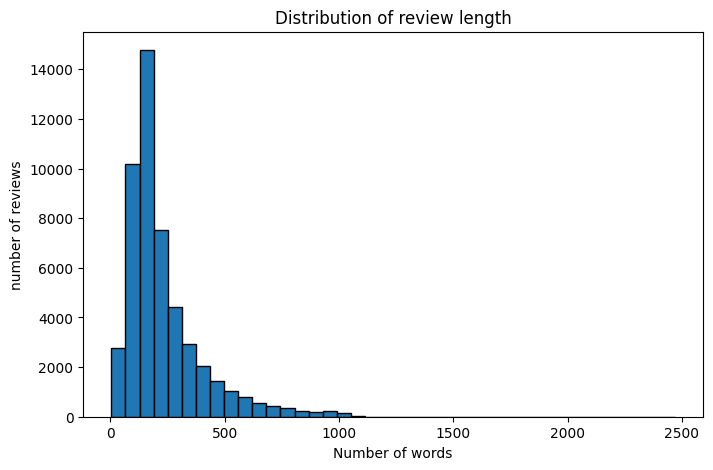

In [12]:
print("Name: Netra Neman, UIN: 231A013")
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["word_count"],bins = 40,edgecolor = "black")

plt.xlabel("Number of words")
plt.ylabel("number of reviews")
plt.title("Distribution of review length")

plt.show()

Name: Netra Neman, UIN: 231A013
total number of words: 11259489
Vocabulary size: 214620


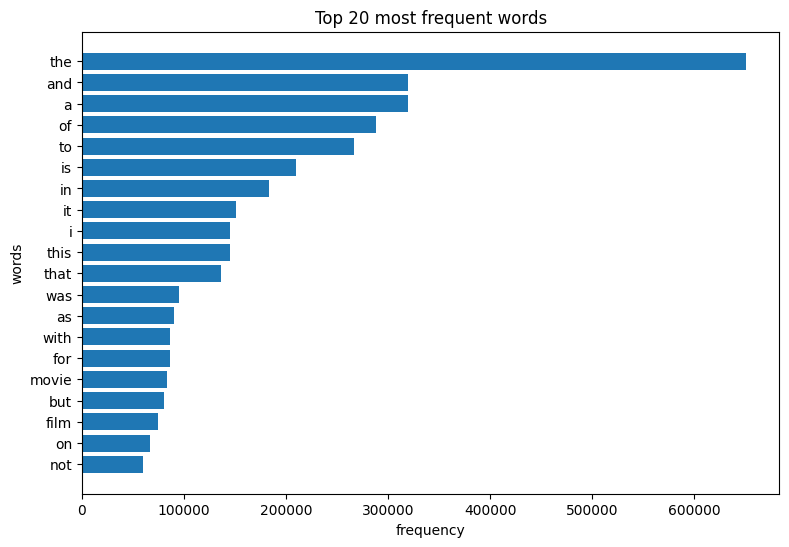

In [14]:
print("Name: Netra Neman, UIN: 231A013")
from collections import Counter
import matplotlib.pyplot as plt

all_words = " ".join(df["clean_text"]).split()

print("total number of words:", len(all_words))
print("Vocabulary size:", len(set(all_words)))

word_freq = Counter(all_words)

top_words = word_freq.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(9, 6))
plt.barh(words[::-1], counts[::-1])
plt.xlabel("frequency")
plt.ylabel("words")
plt.title("Top 20 most frequent words")
plt.show()

Name: Netra Neman, UIN: 231A013


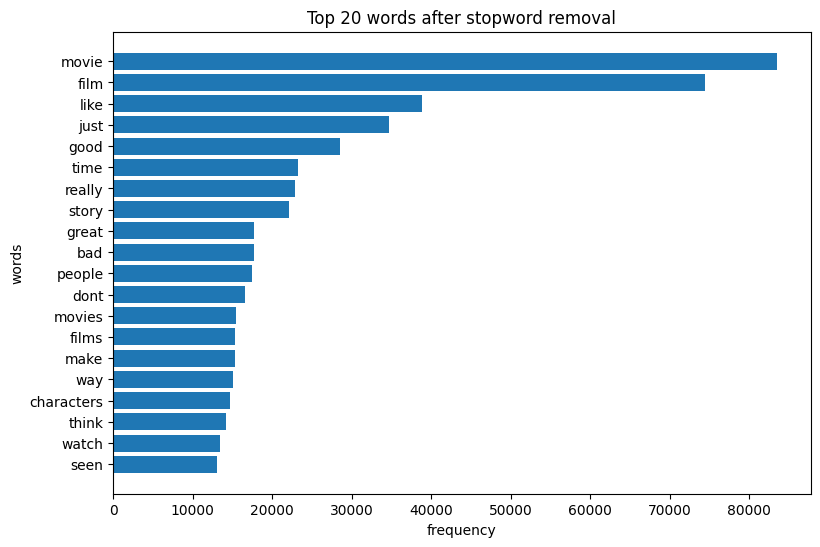

In [16]:
print("Name: Netra Neman, UIN: 231A013")
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt

vectorizer = CountVectorizer(stop_words="english")
vectorizer.fit_transform(df["clean_text"])

stop_words = vectorizer.get_stop_words()
filtered_words = [word for word in all_words if word not in stop_words]

filtered_freq = Counter(filtered_words)
top_filtered = filtered_freq.most_common(20)

words = [word for word, count in top_filtered]
counts = [count for word, count in top_filtered]

plt.figure(figsize=(9, 6))
plt.barh(words[::-1], counts[::-1])
plt.xlabel("frequency")
plt.ylabel("words")
plt.title("Top 20 words after stopword removal")
plt.show()

Name: Netra Neman, UIN: 231A013


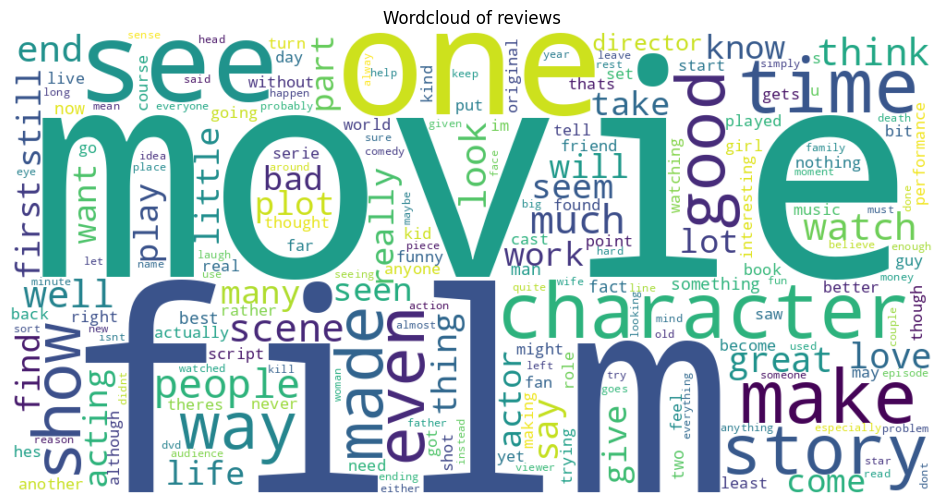

In [18]:
print("Name: Netra Neman, UIN: 231A013")
from wordcloud import WordCloud
import matplotlib.pyplot as plt

clean_text_combined = " ".join(df["clean_text"])

wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(clean_text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud of reviews")
plt.show()

In [19]:
print("Name: Netra Neman, UIN: 231A013")
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20,
)
bigram_matrix = bigram_vectorizer.fit_transform(
    df["clean_text"])
bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_names = bigram_vectorizer.get_feature_names_out()

Name: Netra Neman, UIN: 231A013


In [20]:
print("Name: Netra Neman, UIN: 231A013")
#Top Bigrams
from nltk import ngrams
from collections import Counter
import string

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20,
)
bigram_matrix = bigram_vectorizer.fit_transform(
    df["clean_text"])
bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_names = bigram_vectorizer.get_feature_names_out()
bigram_df = pd.DataFrame(
    {"Bigram": bigram_names,
     "Frequency": bigram_counts}
)
bigram_df = bigram_df.sort_values(
    "Frequency", ascending=False
)

print("\nTop 20 Bigrams:")
print(bigram_df.head(20))

Name: Netra Neman, UIN: 231A013

Top 20 Bigrams:
             Bigram  Frequency
6          ive seen       3300
1         dont know       2193
15  special effects       2134
8        looks like       1661
11       movie just       1477
16       waste time       1425
5           im sure       1369
3        good movie       1363
17      watch movie       1296
2        dont think       1296
7         look like       1291
13         new york       1245
9        low budget       1224
19        years ago       1197
14      pretty good       1073
18         year old       1061
4       high school       1059
10   main character       1041
12       movie like       1038
0         bad movie        979
